# Joe's Pond Ice-Out Analysis

This notebook implements the full workflow:
1. Scrape and cache Joe's Pond ice-out records.
2. Build date/time derived fields and run exploratory plots.
3. Test time trends (OLS, Theil-Sen, Kendall tau).
4. Select nearby NOAA station(s) using distance + data coverage.
5. Build winter climate metrics (Dec 1 previous year -> ice-out date).
6. Correlate winter metrics with ice-out day-of-year.

## 0) Setup

In [1]:
from pathlib import Path
import io
import re
from datetime import datetime

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

DATA_DIR = Path("data")
NCEI_DIR = DATA_DIR / "ncei_daily"
ICEOUT_CSV = DATA_DIR / "joes_pond_iceout.csv"
STATIONS_FILE = DATA_DIR / "ghcnd-stations.txt"

DATA_DIR.mkdir(exist_ok=True)
NCEI_DIR.mkdir(parents=True, exist_ok=True)

# Joe's Pond reference coordinates (hardcoded to avoid extra API calls)
JOES_POND_LAT = 44.40887152650143
JOES_POND_LON = -72.2000267441201

ICEOUT_URL = "https://www.joespondvermont.com/historical-datestimes.html"
GHCN_STATIONS_URL = "https://www1.ncdc.noaa.gov/pub/data/ghcn/daily/ghcnd-stations.txt"
NCEI_DAILY_URL = "https://www.ncei.noaa.gov/access/services/data/v1"

# Request enough temperature fields to build a robust daily temperature estimate.
TEMP_DTYPES = ["TAVG", "TMIN", "TMAX", "TOBS"]
HYDRO_SNOW_DTYPES = ["PRCP", "SNOW", "SNWD"]
NCEI_DTYPES = TEMP_DTYPES + HYDRO_SNOW_DTYPES
# Set True once if you change requested datatypes and want to refresh cached daily files.
REFRESH_NCEI_CACHE = False


## 1) Scrape Joe's Pond page once and cache locally

The parser tries multiple strategies:
- `pandas.read_html` table extraction first.
- Text-pattern fallback for pages that are not cleanly structured as HTML tables.

In [2]:
def _normalize_column_names(columns):
    return [str(c).strip().lower() for c in columns]


def _find_best_table(df_list):
    for df in df_list:
        cols = _normalize_column_names(df.columns)
        has_year = any("year" in c for c in cols)
        has_date = any("date" in c for c in cols)
        has_time = any("time" in c for c in cols)
        if has_year and has_date and has_time:
            return df
    return None


def _coerce_iceout_fields(df):
    df = df.copy()
    col_map = {}
    for c in df.columns:
        lc = str(c).strip().lower()
        if "year" in lc and "year" not in col_map:
            col_map["year"] = c
        if "date" in lc and "date" not in col_map:
            col_map["date"] = c
        if "time" in lc and "time" not in col_map:
            col_map["time"] = c

    if {"year", "date", "time"} - set(col_map):
        raise ValueError("Could not identify Year/Date/Time columns in scraped table.")

    out = df[[col_map["year"], col_map["date"], col_map["time"]]].copy()
    out.columns = ["year", "date_raw", "time_raw"]

    out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
    out["date_raw"] = out["date_raw"].astype(str).str.strip()
    out["time_raw"] = out["time_raw"].astype(str).str.strip()
    out = out.dropna(subset=["year"]).copy()
    out["year"] = out["year"].astype(int)
    return out


def _parse_iceout_date(year, date_text):
    date_text = str(date_text).strip()
    patterns = [
        "%B %d",
        "%b %d",
        "%m/%d",
        "%m-%d",
        "%B %dst",
        "%B %dnd",
        "%B %drd",
        "%B %dth",
    ]

    # remove ordinal suffixes before parsing
    cleaned = re.sub(r"(\d)(st|nd|rd|th)", r"", date_text, flags=re.I)
    cleaned = re.sub(r"\s+", " ", cleaned)

    for fmt in patterns:
        try:
            d = datetime.strptime(cleaned, fmt)
            return pd.Timestamp(year=year, month=d.month, day=d.day)
        except ValueError:
            pass

    # last fallback: let pandas try (month/day text), then force year
    dt = pd.to_datetime(cleaned, errors="coerce")
    if pd.notna(dt):
        return pd.Timestamp(year=year, month=dt.month, day=dt.day)
    return pd.NaT


def _parse_iceout_time(time_text):
    t = str(time_text).strip().upper().replace(".", "")
    t = re.sub(r"\s+", " ", t)

    for fmt in ["%I:%M %p", "%I %p", "%H:%M", "%H%M"]:
        try:
            parsed = datetime.strptime(t, fmt)
            return parsed.hour * 60 + parsed.minute
        except ValueError:
            pass

    # Accept values like 7:05PM
    m = re.match(r"^(\d{1,2}):(\d{2})(AM|PM)$", t)
    if m:
        hh = int(m.group(1)) % 12
        mm = int(m.group(2))
        if m.group(3) == "PM":
            hh += 12
        return hh * 60 + mm

    return np.nan


def _extract_by_text_patterns(html_text):
    soup = BeautifulSoup(html_text, "html.parser")
    raw_text = soup.get_text("\n")
    lines = [ln.strip() for ln in raw_text.splitlines() if ln.strip()]

    records = []
    year_pat = re.compile(r"^(18\d{2}|19\d{2}|20\d{2})$")
    date_pat = re.compile(r"([A-Za-z]{3,9}\.?\s+\d{1,2}(?:st|nd|rd|th)?|\d{1,2}[/-]\d{1,2})")
    time_pat = re.compile(r"(\d{1,2}(?::\d{2})?\s*[APMapm]{2}|\d{1,2}:\d{2})")

    for i, ln in enumerate(lines):
        if year_pat.match(ln):
            year = int(ln)
            window = " ".join(lines[i + 1 : i + 6])
            d_match = date_pat.search(window)
            t_match = time_pat.search(window)
            if d_match and t_match:
                records.append(
                    {
                        "year": year,
                        "date_raw": d_match.group(1).replace(".", ""),
                        "time_raw": t_match.group(1).upper().replace(" ", " "),
                    }
                )

    return pd.DataFrame(records)


def scrape_iceout():
    resp = requests.get(ICEOUT_URL, timeout=30)
    resp.raise_for_status()

    html = resp.text
    dfs = pd.read_html(io.StringIO(html))
    best = _find_best_table(dfs)

    if best is not None:
        ice = _coerce_iceout_fields(best)
    else:
        ice = _extract_by_text_patterns(html)
        if ice.empty:
            raise ValueError("Could not parse ice-out data from page.")

    ice["date"] = [
        _parse_iceout_date(y, d)
        for y, d in zip(ice["year"], ice["date_raw"])
    ]
    ice["minutes_since_midnight"] = ice["time_raw"].map(_parse_iceout_time)

    ice = ice.dropna(subset=["date", "minutes_since_midnight"]).copy()
    ice["minutes_since_midnight"] = ice["minutes_since_midnight"].astype(int)
    ice["time_hhmm"] = (
        (ice["minutes_since_midnight"] // 60).astype(str).str.zfill(2)
        + ":"
        + (ice["minutes_since_midnight"] % 60).astype(str).str.zfill(2)
    )

    # One row per year, keep first if duplicate years appear
    ice = ice.sort_values("year").drop_duplicates("year", keep="first")
    return ice[["year", "date", "time_hhmm", "minutes_since_midnight", "date_raw", "time_raw"]]


def load_iceout(force_rescrape=False):
    if ICEOUT_CSV.exists() and not force_rescrape:
        df = pd.read_csv(ICEOUT_CSV, parse_dates=["date"])
        return df.sort_values("year").reset_index(drop=True)

    df = scrape_iceout()
    df.to_csv(ICEOUT_CSV, index=False)
    return df.sort_values("year").reset_index(drop=True)


ice = load_iceout(force_rescrape=False)
ice.head()

,year,date,time_hhmm,minutes_since_midnight,date_raw,time_raw
0,1988,1988-04-26,12:31,751,4/26,12:31
1,1989,1989-05-05,09:05,545,5/5,9:05
2,1990,1990-04-26,09:40,580,4/26,9:40
3,1991,1991-04-22,04:16,256,4/22,4:16
4,1992,1992-05-06,01:19,79,5/6,1:19


## 2) Quality checks and derived analysis fields

In [3]:
def validate_iceout(df):
    assert not df.empty, "Ice-out dataset is empty."
    dupes = df["year"].duplicated().sum()
    assert dupes == 0, f"Expected unique years, found {dupes} duplicate year rows."

    # Typical Joe's Pond ice-out should be spring-ish and have valid times.
    bad_months = df.loc[~df["date"].dt.month.isin([3, 4, 5, 6])]
    if not bad_months.empty:
        print("Warning: Found dates outside Mar-Jun:")
        display(bad_months[["year", "date", "date_raw"]].head())

    bad_time = df.loc[(df["minutes_since_midnight"] < 0) | (df["minutes_since_midnight"] >= 24 * 60)]
    assert bad_time.empty, "Found invalid time values outside [0, 1440)."


validate_iceout(ice)

ice = ice.copy()
ice["iceout_datetime_local"] = ice["date"] + pd.to_timedelta(ice["minutes_since_midnight"], unit="m")
ice["doy"] = ice["date"].dt.dayofyear
ice["hour_decimal"] = ice["minutes_since_midnight"] / 60

print(f"Rows: {len(ice)} | Year range: {ice['year'].min()}-{ice['year'].max()}")
ice.head()

Rows: 32 | Year range: 1988-2025


,year,date,time_hhmm,minutes_since_midnight,date_raw,time_raw,iceout_datetime_local,doy,hour_decimal
0,1988,1988-04-26,12:31,751,4/26,12:31,1988-04-26 12:31:00,117,12.516667
1,1989,1989-05-05,09:05,545,5/5,9:05,1989-05-05 09:05:00,125,9.083333
2,1990,1990-04-26,09:40,580,4/26,9:40,1990-04-26 09:40:00,116,9.666667
3,1991,1991-04-22,04:16,256,4/22,4:16,1991-04-22 04:16:00,112,4.266667
4,1992,1992-05-06,01:19,79,5/6,1:19,1992-05-06 01:19:00,127,1.316667


## 3) Exploratory plots

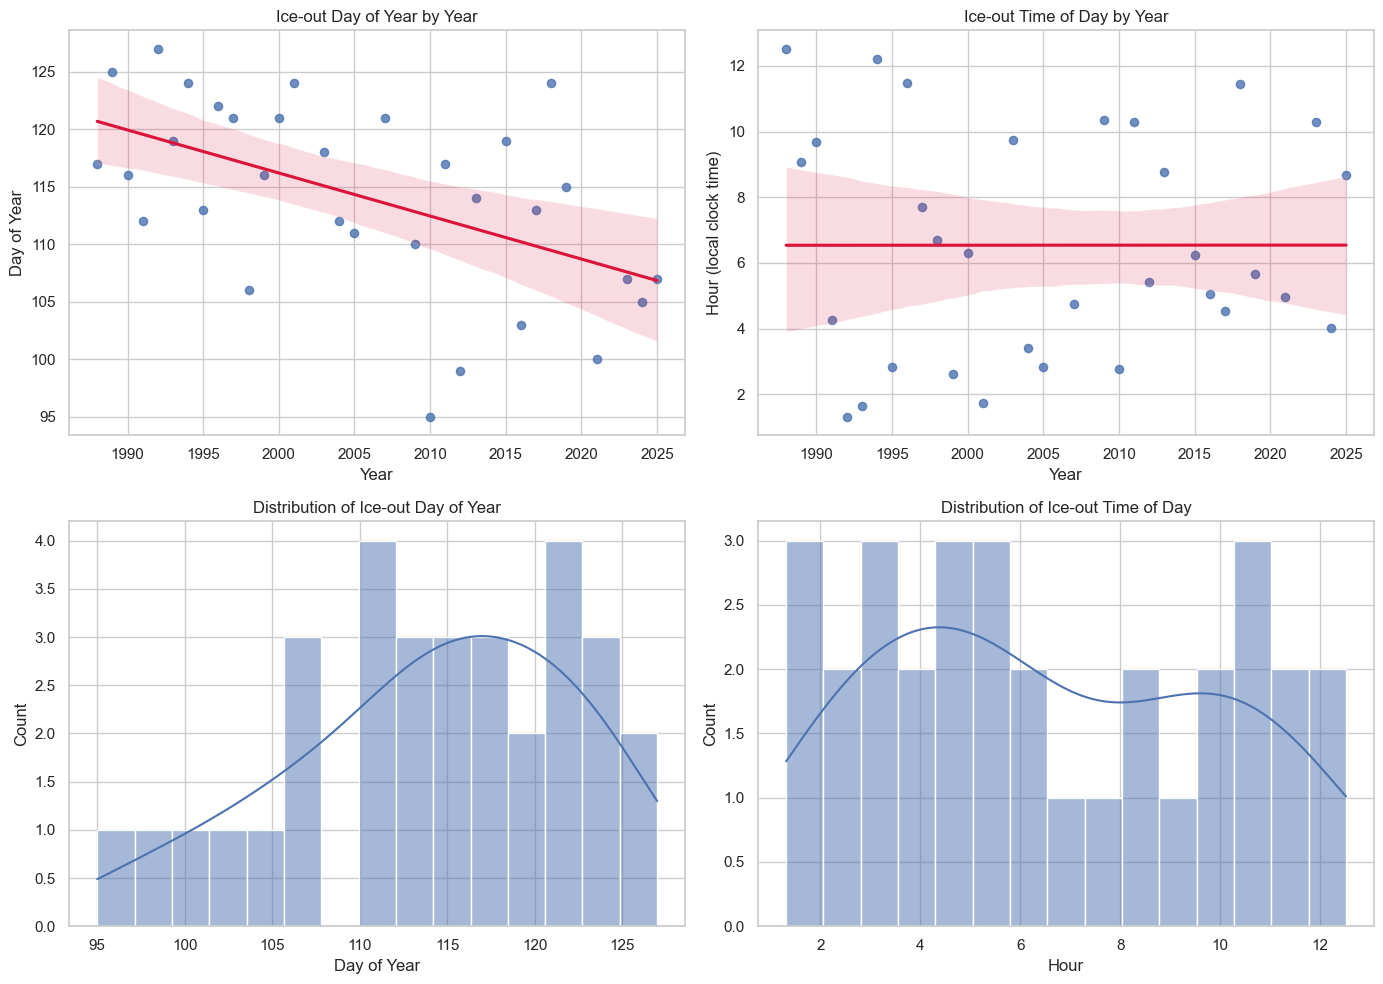

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# DOY vs Year
ax = axes[0, 0]
sns.regplot(data=ice, x="year", y="doy", ax=ax, scatter_kws={"s": 35, "alpha": 0.8}, line_kws={"color": "crimson"})
ax.set_title("Ice-out Day of Year by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Day of Year")

# Time vs Year
ax = axes[0, 1]
sns.regplot(data=ice, x="year", y="hour_decimal", ax=ax, scatter_kws={"s": 35, "alpha": 0.8}, line_kws={"color": "crimson"})
ax.set_title("Ice-out Time of Day by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Hour (local clock time)")

# DOY histogram
ax = axes[1, 0]
sns.histplot(ice["doy"], kde=True, bins=15, ax=ax)
ax.set_title("Distribution of Ice-out Day of Year")
ax.set_xlabel("Day of Year")

# Time histogram
ax = axes[1, 1]
sns.histplot(ice["hour_decimal"], kde=True, bins=15, ax=ax)
ax.set_title("Distribution of Ice-out Time of Day")
ax.set_xlabel("Hour")

plt.tight_layout()
plt.show()

## 4) Trend tests (OLS, Theil-Sen, Kendall tau)

In [5]:
def trend_tests(df, y_col):
    x = df["year"].to_numpy(dtype=float)
    y = df[y_col].to_numpy(dtype=float)

    ols = stats.linregress(x, y)
    ts_slope, ts_intercept, ts_low, ts_high = stats.theilslopes(y, x, 0.95)
    ktau = stats.kendalltau(x, y, nan_policy="omit")

    return {
        "metric": y_col,
        "ols_slope_per_year": ols.slope,
        "ols_pvalue": ols.pvalue,
        "ols_rvalue": ols.rvalue,
        "theil_sen_slope_per_year": ts_slope,
        "theil_sen_ci_low": ts_low,
        "theil_sen_ci_high": ts_high,
        "kendall_tau": ktau.statistic,
        "kendall_pvalue": ktau.pvalue,
    }

trend_df = pd.DataFrame([
    trend_tests(ice, "doy"),
    trend_tests(ice, "minutes_since_midnight"),
])

trend_df

,metric,ols_slope_per_year,ols_pvalue,ols_rvalue,theil_sen_slope_per_year,theil_sen_ci_low,theil_sen_ci_high,kendall_tau,kendall_pvalue
0,doy,-0.374159,0.002192,-0.521789,-0.361818,-0.600000,-0.142857,-0.359211,0.004248
1,minutes_since_midnight,0.008785,0.997886,0.000488,0.041667,-6.916667,7.333333,0.002018,0.987060


## 5) NOAA station metadata: nearest candidates + coverage scoring

Nearest station is not always best. This section ranks nearby stations using:
- Distance to Joe's Pond
- Coverage completeness across snow/hydrology variables (`PRCP`, `SNOW`, `SNWD`)
- A robust temperature coverage score built from `TAVG` first, then `(TMIN+TMAX)/2`, then `TOBS`

In [6]:
def download_stations(force=False):
    if STATIONS_FILE.exists() and not force:
        return STATIONS_FILE

    resp = requests.get(GHCN_STATIONS_URL, timeout=60)
    resp.raise_for_status()
    STATIONS_FILE.write_text(resp.text)
    return STATIONS_FILE


def parse_ghcnd_stations(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for ln in f:
            station_id = ln[0:11].strip()
            lat = ln[12:20].strip()
            lon = ln[21:30].strip()
            elev = ln[31:37].strip()
            state = ln[38:40].strip()
            name = ln[41:71].strip()
            gsn = ln[72:75].strip()
            hcn = ln[76:79].strip()
            wmo = ln[80:85].strip()

            if not station_id:
                continue

            rows.append({
                "station": station_id,
                "lat": pd.to_numeric(lat, errors="coerce"),
                "lon": pd.to_numeric(lon, errors="coerce"),
                "elev_m": pd.to_numeric(elev, errors="coerce"),
                "state": state,
                "name": name,
                "gsn": gsn,
                "hcn": hcn,
                "wmo": wmo,
            })
    return pd.DataFrame(rows)


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1 = np.radians(lat1)
    p2 = np.radians(lat2)
    dp = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)
    a = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


stations_path = download_stations(force=False)
stations = parse_ghcnd_stations(stations_path)

# Focus on Vermont first; can expand later if needed.
vt = stations.query("state == 'VT'").copy()
vt = vt.dropna(subset=["lat", "lon"]).copy()
vt["distance_km"] = haversine_km(JOES_POND_LAT, JOES_POND_LON, vt["lat"].values, vt["lon"].values)

nearest_n = 12
candidates = vt.sort_values("distance_km").head(nearest_n).reset_index(drop=True)
candidates[["station", "name", "distance_km", "lat", "lon"]]

,station,name,distance_km,lat,lon
0,USC00439184,WEST DANVILLE 2,0.939608,44.4161,-72.1939
1,USC00439182,WEST DANVILLE,1.654915,44.4000,-72.1833
2,US1VTWS0012,CABOT 3.9 ENE,2.924665,44.4171,-72.2350
3,US1VTCL0030,DANVILLE 2.2 NW,3.258539,44.4317,-72.1743
4,US1VTCL0027,DANVILLE 0.4 N,4.914487,44.4177,-72.1394
5,US1VTWS0023,CABOT 2.3 E,5.352871,44.3981,-72.2657
6,USC00431715,DANVILLE,5.371007,44.4167,-72.1333
7,US1VTCL0038,PEACHAM 1.3 NW,7.709551,44.3398,-72.1916
8,US1VTCL0044,DANVILLE 3.1 NNE,7.827438,44.4547,-72.1252
9,US1VTCL0006,DANVILLE 2.0 E,7.945948,44.4122,-72.1001


## 6) NOAA daily retrieval helpers with local caching

In [7]:
def _daily_cache_path(station, start_date, end_date):
    return NCEI_DIR / f"{station}_{start_date}_{end_date}.csv"


def fetch_ncei_daily(station, start_date, end_date, force=False):
    cache_path = _daily_cache_path(station, start_date, end_date)
    if cache_path.exists() and not force:
        return pd.read_csv(cache_path, parse_dates=["DATE"], low_memory=False)

    params = {
        "dataset": "daily-summaries",
        "stations": station,
        "startDate": start_date,
        "endDate": end_date,
        "dataTypes": ",".join(NCEI_DTYPES),
        "format": "csv",
        "units": "metric",
        "includeAttributes": "false",
    }

    resp = requests.get(NCEI_DAILY_URL, params=params, timeout=90)
    resp.raise_for_status()

    if not resp.text.strip():
        df = pd.DataFrame()
    else:
        df = pd.read_csv(io.StringIO(resp.text), low_memory=False)

    if "DATE" in df.columns:
        df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")

    df.to_csv(cache_path, index=False)
    return df


def temp_estimate_series(df):
    idx = df.index
    tavg = pd.to_numeric(df["TAVG"], errors="coerce") if "TAVG" in df else pd.Series(np.nan, index=idx)
    tmin = pd.to_numeric(df["TMIN"], errors="coerce") if "TMIN" in df else pd.Series(np.nan, index=idx)
    tmax = pd.to_numeric(df["TMAX"], errors="coerce") if "TMAX" in df else pd.Series(np.nan, index=idx)
    tobs = pd.to_numeric(df["TOBS"], errors="coerce") if "TOBS" in df else pd.Series(np.nan, index=idx)

    tminmax = (tmin + tmax) / 2
    temp_est = tavg.combine_first(tminmax).combine_first(tobs)
    return temp_est, tavg, tmin, tmax, tobs


def coverage_score(df):
    if df.empty:
        return {
            "temp_est_coverage": 0.0,
            "TAVG_coverage": 0.0,
            "TMIN_TMAX_pair_coverage": 0.0,
            "TOBS_coverage": 0.0,
            "PRCP_coverage": 0.0,
            "SNOW_coverage": 0.0,
            "SNWD_coverage": 0.0,
            "coverage_mean": 0.0,
            "row_count": 0,
        }

    temp_est, tavg, tmin, tmax, tobs = temp_estimate_series(df)
    tmin_tmax_pair_cov = (tmin.notna() & tmax.notna()).mean()

    cov = {
        "temp_est_coverage": temp_est.notna().mean(),
        "TAVG_coverage": tavg.notna().mean(),
        "TMIN_TMAX_pair_coverage": tmin_tmax_pair_cov,
        "TOBS_coverage": tobs.notna().mean(),
        "PRCP_coverage": df["PRCP"].notna().mean() if "PRCP" in df else 0.0,
        "SNOW_coverage": df["SNOW"].notna().mean() if "SNOW" in df else 0.0,
        "SNWD_coverage": df["SNWD"].notna().mean() if "SNWD" in df else 0.0,
    }

    cov["coverage_mean"] = float(np.mean([
        cov["temp_est_coverage"],
        cov["PRCP_coverage"],
        cov["SNOW_coverage"],
        cov["SNWD_coverage"],
    ]))
    cov["row_count"] = len(df)
    return cov

## 7) Pick best viable station among nearest candidates

In [8]:
analysis_start = f"{ice['year'].min() - 1}-12-01"
analysis_end = ice["date"].max().strftime("%Y-%m-%d")

station_scores = []
for _, row in candidates.iterrows():
    station = row["station"]
    try:
        d = fetch_ncei_daily(station, analysis_start, analysis_end, force=REFRESH_NCEI_CACHE)
        cov = coverage_score(d)
    except Exception as e:
        cov = {
            "temp_est_coverage": 0.0,
            "TAVG_coverage": 0.0,
            "TMIN_TMAX_pair_coverage": 0.0,
            "TOBS_coverage": 0.0,
            "PRCP_coverage": 0.0,
            "SNOW_coverage": 0.0,
            "SNWD_coverage": 0.0,
            "coverage_mean": 0.0,
            "row_count": 0,
            "error": str(e),
        }

    station_scores.append({
        "station": station,
        "name": row["name"],
        "distance_km": row["distance_km"],
        **cov,
    })

station_rank = pd.DataFrame(station_scores).sort_values(
    ["coverage_mean", "temp_est_coverage", "SNOW_coverage", "SNWD_coverage", "distance_km"],
    ascending=[False, False, False, False, True],
).reset_index(drop=True)

station_rank.head(10)

,station,name,distance_km,temp_est_coverage,TAVG_coverage,TMIN_TMAX_pair_coverage,TOBS_coverage,PRCP_coverage,SNOW_coverage,SNWD_coverage,coverage_mean,row_count
0,USC00439184,WEST DANVILLE 2,0.939608,0.910084,0.0,0.908491,0.909629,0.975415,0.993399,0.896198,0.943774,4393
1,US1VTCL0044,DANVILLE 3.1 NNE,7.827438,0.000000,0.0,0.000000,0.000000,0.983034,0.856287,0.565868,0.601297,1002
2,US1VTCL0027,DANVILLE 0.4 N,4.914487,0.000000,0.0,0.000000,0.000000,0.985882,0.693182,0.109160,0.447056,2904
3,US1VTWS0012,CABOT 3.9 ENE,2.924665,0.000000,0.0,0.000000,0.000000,0.984723,0.597052,0.109633,0.422852,5564
4,US1VTCL0030,DANVILLE 2.2 NW,3.258539,0.000000,0.0,0.000000,0.000000,0.989157,0.686747,0.005422,0.420331,1660
5,US1VTCL0006,DANVILLE 2.0 E,7.945948,0.000000,0.0,0.000000,0.000000,0.960265,0.514487,0.185430,0.415046,2416
6,US1VTWS0023,CABOT 2.3 E,5.352871,0.000000,0.0,0.000000,0.000000,0.959246,0.598319,0.102394,0.414990,3926
7,US1VTCL0038,PEACHAM 1.3 NW,7.709551,0.000000,0.0,0.000000,0.000000,0.949045,0.248408,0.012739,0.302548,157
8,US1VTCL0041,DANVILLE 4.0 SE,10.297330,0.000000,0.0,0.000000,0.000000,0.933735,0.209337,0.013554,0.289157,664
9,USC00439182,WEST DANVILLE,1.654915,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0


### Choose station

Set `CHOSEN_STATION` after inspecting the ranking table above.
Default behavior below picks rank 1.

In [9]:
CHOSEN_STATION = station_rank.loc[0, "station"]
print("Chosen station:", CHOSEN_STATION)
station_rank.loc[station_rank["station"] == CHOSEN_STATION].head(1)

Chosen station: USC00439184


,station,name,distance_km,temp_est_coverage,TAVG_coverage,TMIN_TMAX_pair_coverage,TOBS_coverage,PRCP_coverage,SNOW_coverage,SNWD_coverage,coverage_mean,row_count
0,USC00439184,WEST DANVILLE 2,0.939608,0.910084,0.0,0.908491,0.909629,0.975415,0.993399,0.896198,0.943774,4393


## 8) Build winter windows and compute climate metrics per ice-out year

Winter window definition (agreed baseline):
- Start = Dec 1 of previous year
- End = ice-out date in current year

In [10]:
def compute_winter_window(year, iceout_date):
    start = pd.Timestamp(year=year - 1, month=12, day=1)
    end = pd.Timestamp(iceout_date).normalize()
    return start, end


def normalize_numeric(df, cols):
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out


winter_rows = []

for _, r in ice.iterrows():
    year = int(r["year"])
    ice_date = pd.Timestamp(r["date"])
    start, end = compute_winter_window(year, ice_date)

    ds = fetch_ncei_daily(CHOSEN_STATION, start.strftime("%Y-%m-%d"), end.strftime("%Y-%m-%d"), force=REFRESH_NCEI_CACHE)
    ds = normalize_numeric(ds, NCEI_DTYPES)

    if "DATE" in ds.columns:
        ds = ds.sort_values("DATE")

    temp_est, tavg, tmin, tmax, tobs = temp_estimate_series(ds)

    # Degree days in Celsius baseline (0 C), based on robust daily temperature estimate
    freezing_deg_days = np.maximum(0, 0 - temp_est).sum(skipna=True)
    thaw_deg_days = np.maximum(0, temp_est - 0).sum(skipna=True)

    winter_rows.append({
        "year": year,
        "winter_start": start,
        "winter_end": end,
        "winter_days": (end - start).days + 1,
        "n_daily_rows": len(ds),
        "temp_mean_c": temp_est.mean(skipna=True),
        "temp_std_c": temp_est.std(skipna=True),
        "freezing_degree_days_c": freezing_deg_days,
        "thaw_degree_days_c": thaw_deg_days,
        "prcp_total_mm": ds["PRCP"].sum(skipna=True) if "PRCP" in ds else np.nan,
        "snow_total_mm": ds["SNOW"].sum(skipna=True) if "SNOW" in ds else np.nan,
        "snwd_max_mm": ds["SNWD"].max(skipna=True) if "SNWD" in ds else np.nan,
        "temp_est_cov": temp_est.notna().mean(),
        "tavg_cov": tavg.notna().mean(),
        "tmin_tmax_pair_cov": (tmin.notna() & tmax.notna()).mean(),
        "tobs_cov": tobs.notna().mean(),
        "prcp_cov": ds["PRCP"].notna().mean() if "PRCP" in ds else 0,
        "snow_cov": ds["SNOW"].notna().mean() if "SNOW" in ds else 0,
        "snwd_cov": ds["SNWD"].notna().mean() if "SNWD" in ds else 0,
        "temp_days_from_tavg": int(tavg.notna().sum()),
        "temp_days_from_tmin_tmax": int((tmin.notna() & tmax.notna()).sum()),
        "temp_days_from_tobs": int(tobs.notna().sum()),
    })

winter = pd.DataFrame(winter_rows).sort_values("year").reset_index(drop=True)
analysis_df = ice.merge(winter, on="year", how="left")

analysis_df.head()

,year,date,time_hhmm,minutes_since_midnight,date_raw,time_raw,iceout_datetime_local,doy,hour_decimal,winter_start,winter_end,winter_days,n_daily_rows,temp_mean_c,temp_std_c,freezing_degree_days_c,thaw_degree_days_c,prcp_total_mm,snow_total_mm,snwd_max_mm,temp_est_cov,tavg_cov,tmin_tmax_pair_cov,tobs_cov,prcp_cov,snow_cov,snwd_cov,temp_days_from_tavg,temp_days_from_tmin_tmax,temp_days_from_tobs
0,1988,1988-04-26,12:31,751,4/26,12:31,1988-04-26 12:31:00,117,12.516667,1987-12-01,1988-04-26,148,0,NaN,NaN,0.00,0.00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
1,1989,1989-05-05,09:05,545,5/5,9:05,1989-05-05 09:05:00,125,9.083333,1988-12-01,1989-05-05,156,5,NaN,NaN,0.00,0.00,41.4,0.0,0.0,0.000000,0.0,0.000000,0.000000,1.000000,1.000000,1.000000,0,0,0
2,1990,1990-04-26,09:40,580,4/26,9:40,1990-04-26 09:40:00,116,9.666667,1989-12-01,1990-04-26,147,147,3.438462,4.140611,11.65,101.05,384.0,2749.0,864.0,0.176871,0.0,0.176871,0.176871,1.000000,1.000000,0.727891,0,26,26
3,1991,1991-04-22,04:16,256,4/22,4:16,1991-04-22 04:16:00,112,4.266667,1990-12-01,1991-04-22,143,143,-3.884266,7.735116,760.35,204.90,358.8,1787.0,508.0,1.000000,0.0,1.000000,1.000000,1.000000,0.986014,0.503497,0,143,143
4,1992,1992-05-06,01:19,79,5/6,1:19,1992-05-06 01:19:00,127,1.316667,1991-12-01,1992-05-06,158,158,-5.416456,8.348379,1058.60,202.80,399.7,2943.0,610.0,1.000000,0.0,1.000000,0.993671,0.987342,0.987342,0.367089,0,158,157


## 9) Correlate winter metrics with ice-out timing (DOY)

In [11]:
metrics = [
    "temp_mean_c",
    "temp_std_c",
    "freezing_degree_days_c",
    "thaw_degree_days_c",
    "prcp_total_mm",
    "snow_total_mm",
    "snwd_max_mm",
]

corr_rows = []
for m in metrics:
    sub = analysis_df[["doy", m]].dropna()
    if len(sub) < 5:
        continue

    pear = stats.pearsonr(sub[m], sub["doy"])
    spear = stats.spearmanr(sub[m], sub["doy"], nan_policy="omit")

    corr_rows.append({
        "metric": m,
        "n": len(sub),
        "pearson_r": pear.statistic,
        "pearson_p": pear.pvalue,
        "spearman_rho": spear.statistic,
        "spearman_p": spear.pvalue,
        "abs_pearson_r": abs(pear.statistic),
    })

corr_df = pd.DataFrame(corr_rows).sort_values("abs_pearson_r", ascending=False)
corr_df

,metric,n,pearson_r,pearson_p,spearman_rho,spearman_p,abs_pearson_r
5,snow_total_mm,32,0.402460,0.022394,0.422599,0.015971,0.402460
2,freezing_degree_days_c,32,0.385618,0.029281,0.419434,0.016864,0.385618
4,prcp_total_mm,32,0.383255,0.030372,0.456833,0.008579,0.383255
3,thaw_degree_days_c,32,0.340291,0.056688,0.324497,0.069988,0.340291
0,temp_mean_c,12,-0.265580,0.404117,-0.568425,0.053807,0.265580
1,temp_std_c,12,0.243843,0.445016,0.470178,0.122957,0.243843
6,snwd_max_mm,13,-0.039263,0.898665,-0.113104,0.712952,0.039263


## 10) Build spring windows (Feb 20 -> ice-out) and compute climate metrics

Spring window definition:
- Start = Feb 20 of ice-out year
- End = ice-out date in current year


In [12]:
def compute_spring_window(year, iceout_date):
    start = pd.Timestamp(year=year, month=2, day=20)
    end = pd.Timestamp(iceout_date).normalize()
    return start, end


spring_rows = []

for _, r in ice.iterrows():
    year = int(r["year"])
    ice_date = pd.Timestamp(r["date"])
    start, end = compute_spring_window(year, ice_date)

    ds = fetch_ncei_daily(CHOSEN_STATION, start.strftime("%Y-%m-%d"), end.strftime("%Y-%m-%d"), force=REFRESH_NCEI_CACHE)
    ds = normalize_numeric(ds, NCEI_DTYPES)

    if "DATE" in ds.columns:
        ds = ds.sort_values("DATE")

    temp_est, tavg, tmin, tmax, tobs = temp_estimate_series(ds)

    freezing_deg_days = np.maximum(0, 0 - temp_est).sum(skipna=True)
    thaw_deg_days = np.maximum(0, temp_est - 0).sum(skipna=True)

    spring_rows.append({
        "year": year,
        "spring_start": start,
        "spring_end": end,
        "spring_days": (end - start).days + 1,
        "spring_n_daily_rows": len(ds),
        "spring_temp_mean_c": temp_est.mean(skipna=True),
        "spring_temp_std_c": temp_est.std(skipna=True),
        "spring_freezing_degree_days_c": freezing_deg_days,
        "spring_thaw_degree_days_c": thaw_deg_days,
        "spring_prcp_total_mm": ds["PRCP"].sum(skipna=True) if "PRCP" in ds else np.nan,
        "spring_snow_total_mm": ds["SNOW"].sum(skipna=True) if "SNOW" in ds else np.nan,
        "spring_snwd_max_mm": ds["SNWD"].max(skipna=True) if "SNWD" in ds else np.nan,
        "spring_temp_est_cov": temp_est.notna().mean(),
        "spring_tavg_cov": tavg.notna().mean(),
        "spring_tmin_tmax_pair_cov": (tmin.notna() & tmax.notna()).mean(),
        "spring_tobs_cov": tobs.notna().mean(),
        "spring_prcp_cov": ds["PRCP"].notna().mean() if "PRCP" in ds else 0,
        "spring_snow_cov": ds["SNOW"].notna().mean() if "SNOW" in ds else 0,
        "spring_snwd_cov": ds["SNWD"].notna().mean() if "SNWD" in ds else 0,
    })

spring = pd.DataFrame(spring_rows).sort_values("year").reset_index(drop=True)
analysis_spring_df = ice.merge(spring, on="year", how="left")

analysis_spring_df.head()


,year,date,time_hhmm,minutes_since_midnight,date_raw,time_raw,iceout_datetime_local,doy,hour_decimal,spring_start,spring_end,spring_days,spring_n_daily_rows,spring_temp_mean_c,spring_temp_std_c,spring_freezing_degree_days_c,spring_thaw_degree_days_c,spring_prcp_total_mm,spring_snow_total_mm,spring_snwd_max_mm,spring_temp_est_cov,spring_tavg_cov,spring_tmin_tmax_pair_cov,spring_tobs_cov,spring_prcp_cov,spring_snow_cov,spring_snwd_cov
0,1988,1988-04-26,12:31,751,4/26,12:31,1988-04-26 12:31:00,117,12.516667,1988-02-20,1988-04-26,67,0,NaN,NaN,0.00,0.00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1989,1989-05-05,09:05,545,5/5,9:05,1989-05-05 09:05:00,125,9.083333,1989-02-20,1989-05-05,75,5,NaN,NaN,0.00,0.00,41.4,0.0,0.0,0.000000,0.0,0.000000,0.000000,1.000000,1.000000,1.000000
2,1990,1990-04-26,09:40,580,4/26,9:40,1990-04-26 09:40:00,116,9.666667,1990-02-20,1990-04-26,66,66,3.438462,4.140611,11.65,101.05,194.4,778.0,610.0,0.393939,0.0,0.393939,0.393939,1.000000,1.000000,0.545455
3,1991,1991-04-22,04:16,256,4/22,4:16,1991-04-22 04:16:00,112,4.266667,1991-02-20,1991-04-22,62,62,0.084677,6.815223,159.00,164.25,155.7,320.0,330.0,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,0.387097
4,1992,1992-05-06,01:19,79,5/6,1:19,1992-05-06 01:19:00,127,1.316667,1992-02-20,1992-05-06,77,77,-1.674675,7.551710,306.50,177.55,200.8,1115.0,305.0,1.000000,0.0,1.000000,1.000000,0.987013,0.974026,0.090909


## 11) Correlate spring metrics with ice-out timing (DOY)


In [13]:
spring_metrics = [
    "spring_temp_mean_c",
    "spring_temp_std_c",
    "spring_freezing_degree_days_c",
    "spring_thaw_degree_days_c",
    "spring_prcp_total_mm",
    "spring_snow_total_mm",
    "spring_snwd_max_mm",
]

spring_corr_rows = []
for m in spring_metrics:
    sub = analysis_spring_df[["doy", m]].dropna()
    if len(sub) < 5:
        continue

    pear = stats.pearsonr(sub[m], sub["doy"])
    spear = stats.spearmanr(sub[m], sub["doy"], nan_policy="omit")

    spring_corr_rows.append({
        "metric": m,
        "n": len(sub),
        "pearson_r": pear.statistic,
        "pearson_p": pear.pvalue,
        "spearman_rho": spear.statistic,
        "spearman_p": spear.pvalue,
        "abs_pearson_r": abs(pear.statistic),
    })

spring_corr_df = pd.DataFrame(spring_corr_rows).sort_values("abs_pearson_r", ascending=False)
spring_corr_df


,metric,n,pearson_r,pearson_p,spearman_rho,spearman_p,abs_pearson_r
5,spring_snow_total_mm,32,0.414797,0.018248,0.385801,0.029198,0.414797
4,spring_prcp_total_mm,32,0.413934,0.018515,0.429774,0.014091,0.413934
2,spring_freezing_degree_days_c,32,0.387952,0.028234,0.374537,0.034689,0.387952
3,spring_thaw_degree_days_c,32,0.358743,0.043769,0.361106,0.042301,0.358743
0,spring_temp_mean_c,11,-0.243624,0.470356,-0.347036,0.295735,0.243624
1,spring_temp_std_c,11,0.176579,0.603497,0.328771,0.323554,0.176579
6,spring_snwd_max_mm,12,0.000942,0.997681,-0.172232,0.592470,0.000942


## 12) Compare winter vs spring correlation strength


In [14]:
winter_map = {
    "temp_mean_c": "temp_mean",
    "temp_std_c": "temp_std",
    "freezing_degree_days_c": "freezing_degree_days",
    "thaw_degree_days_c": "thaw_degree_days",
    "prcp_total_mm": "prcp_total",
    "snow_total_mm": "snow_total",
    "snwd_max_mm": "snwd_max",
}

spring_map = {
    "spring_temp_mean_c": "temp_mean",
    "spring_temp_std_c": "temp_std",
    "spring_freezing_degree_days_c": "freezing_degree_days",
    "spring_thaw_degree_days_c": "thaw_degree_days",
    "spring_prcp_total_mm": "prcp_total",
    "spring_snow_total_mm": "snow_total",
    "spring_snwd_max_mm": "snwd_max",
}

winter_cmp = corr_df[["metric", "pearson_r", "pearson_p", "spearman_rho", "spearman_p"]].copy()
winter_cmp["metric_family"] = winter_cmp["metric"].map(winter_map)
winter_cmp = winter_cmp.rename(columns={
    "pearson_r": "winter_pearson_r",
    "pearson_p": "winter_pearson_p",
    "spearman_rho": "winter_spearman_rho",
    "spearman_p": "winter_spearman_p",
})

spring_cmp = spring_corr_df[["metric", "pearson_r", "pearson_p", "spearman_rho", "spearman_p"]].copy()
spring_cmp["metric_family"] = spring_cmp["metric"].map(spring_map)
spring_cmp = spring_cmp.rename(columns={
    "pearson_r": "spring_pearson_r",
    "pearson_p": "spring_pearson_p",
    "spearman_rho": "spring_spearman_rho",
    "spearman_p": "spring_spearman_p",
})

window_compare = winter_cmp.merge(spring_cmp, on="metric_family", how="outer")
window_compare = window_compare[[
    "metric_family",
    "winter_pearson_r", "winter_pearson_p", "winter_spearman_rho", "winter_spearman_p",
    "spring_pearson_r", "spring_pearson_p", "spring_spearman_rho", "spring_spearman_p",
]].sort_values("metric_family")

window_compare


,metric_family,winter_pearson_r,winter_pearson_p,winter_spearman_rho,winter_spearman_p,spring_pearson_r,spring_pearson_p,spring_spearman_rho,spring_spearman_p
0,freezing_degree_days,0.385618,0.029281,0.419434,0.016864,0.387952,0.028234,0.374537,0.034689
1,prcp_total,0.383255,0.030372,0.456833,0.008579,0.413934,0.018515,0.429774,0.014091
2,snow_total,0.402460,0.022394,0.422599,0.015971,0.414797,0.018248,0.385801,0.029198
3,snwd_max,-0.039263,0.898665,-0.113104,0.712952,0.000942,0.997681,-0.172232,0.592470
4,temp_mean,-0.265580,0.404117,-0.568425,0.053807,-0.243624,0.470356,-0.347036,0.295735
5,temp_std,0.243843,0.445016,0.470178,0.122957,0.176579,0.603497,0.328771,0.323554
6,thaw_degree_days,0.340291,0.056688,0.324497,0.069988,0.358743,0.043769,0.361106,0.042301


## 13) Overall predictive comparison: winter vs spring vs combined

This section compares feature sets by out-of-sample predictive performance using leave-one-out cross-validation (LOOCV):
- Winter metrics only
- Spring metrics only
- Winter + Spring metrics

Targets evaluated:
- `doy` (ice-out date within year)
- `minutes_since_midnight` (ice-out time-of-day)


In [15]:
winter_features = [
    "temp_mean_c",
    "temp_std_c",
    "freezing_degree_days_c",
    "thaw_degree_days_c",
    "prcp_total_mm",
    "snow_total_mm",
    "snwd_max_mm",
]

spring_features = [
    "spring_temp_mean_c",
    "spring_temp_std_c",
    "spring_freezing_degree_days_c",
    "spring_thaw_degree_days_c",
    "spring_prcp_total_mm",
    "spring_snow_total_mm",
    "spring_snwd_max_mm",
]

model_df = analysis_df[["year", "doy", "minutes_since_midnight", *winter_features]].merge(
    analysis_spring_df[["year", *spring_features]],
    on="year",
    how="inner",
)


def loocv_linear_regression(df, feature_cols, target_col, min_samples=12):
    cols = feature_cols + [target_col]
    d = df[cols].dropna().copy()
    n = len(d)
    p = len(feature_cols)

    # Guardrails for very small samples relative to number of predictors.
    if n < max(min_samples, p + 3):
        return {
            "n": n,
            "p": p,
            "mae": np.nan,
            "rmse": np.nan,
            "cv_r2": np.nan,
            "pred_obs_spearman": np.nan,
            "status": "insufficient_rows",
            "y_true": np.array([]),
            "y_pred": np.array([]),
        }

    X = d[feature_cols].to_numpy(dtype=float)
    y = d[target_col].to_numpy(dtype=float)
    preds = np.full(n, np.nan)

    for i in range(n):
        mask = np.ones(n, dtype=bool)
        mask[i] = False

        X_train = X[mask]
        y_train = y[mask]
        X_test = X[~mask]

        mu = X_train.mean(axis=0)
        sigma = X_train.std(axis=0, ddof=0)
        sigma[sigma == 0] = 1.0

        X_train_z = (X_train - mu) / sigma
        X_test_z = (X_test - mu) / sigma

        X_train_design = np.column_stack([np.ones(X_train_z.shape[0]), X_train_z])
        X_test_design = np.column_stack([np.ones(X_test_z.shape[0]), X_test_z])

        beta = np.linalg.pinv(X_train_design) @ y_train
        preds[i] = np.asarray(X_test_design @ beta).ravel()[0]

    residuals = y - preds
    mae = float(np.mean(np.abs(residuals)))
    rmse = float(np.sqrt(np.mean(residuals ** 2)))

    sse = float(np.sum((y - preds) ** 2))
    sst = float(np.sum((y - y.mean()) ** 2))
    cv_r2 = np.nan if sst == 0 else 1 - (sse / sst)

    rho = stats.spearmanr(y, preds, nan_policy="omit").statistic

    return {
        "n": n,
        "p": p,
        "mae": mae,
        "rmse": rmse,
        "cv_r2": cv_r2,
        "pred_obs_spearman": rho,
        "status": "ok",
        "y_true": y,
        "y_pred": preds,
    }


def evaluate_feature_sets(target_col):
    sets = {
        "winter_only": winter_features,
        "spring_only": spring_features,
        "winter_plus_spring": winter_features + spring_features,
    }

    rows = []
    details = {}
    for name, feats in sets.items():
        res = loocv_linear_regression(model_df, feats, target_col)
        rows.append({
            "target": target_col,
            "feature_set": name,
            "n": res["n"],
            "p": res["p"],
            "mae": res["mae"],
            "rmse": res["rmse"],
            "cv_r2": res["cv_r2"],
            "pred_obs_spearman": res["pred_obs_spearman"],
            "status": res["status"],
        })
        details[(target_col, name)] = res

    out = pd.DataFrame(rows).sort_values(["target", "rmse"], ascending=[True, True])
    return out, details


pred_doy_df, pred_doy_details = evaluate_feature_sets("doy")
pred_time_df, pred_time_details = evaluate_feature_sets("minutes_since_midnight")
predictive_compare = pd.concat([pred_doy_df, pred_time_df], ignore_index=True)

predictive_compare


,target,feature_set,n,p,mae,rmse,cv_r2,pred_obs_spearman,status
0,doy,winter_only,12,7,26.176805,50.307831,-82.225944,0.340353,ok
1,doy,spring_only,11,7,NaN,NaN,NaN,NaN,insufficient_rows
2,doy,winter_plus_spring,11,14,NaN,NaN,NaN,NaN,insufficient_rows
3,minutes_since_midnight,winter_only,12,7,386.316447,611.747230,-7.797881,0.356643,ok
4,minutes_since_midnight,spring_only,11,7,NaN,NaN,NaN,NaN,insufficient_rows
5,minutes_since_midnight,winter_plus_spring,11,14,NaN,NaN,NaN,NaN,insufficient_rows


### Interpretation guide

- Lower `RMSE` / `MAE` is better.
- Higher `cv_r2` is better (can be negative if predictions are worse than using the mean).
- Higher `pred_obs_spearman` means better monotonic agreement.


Best feature set for DOY: winter_only
Best feature set for time-of-day: winter_only


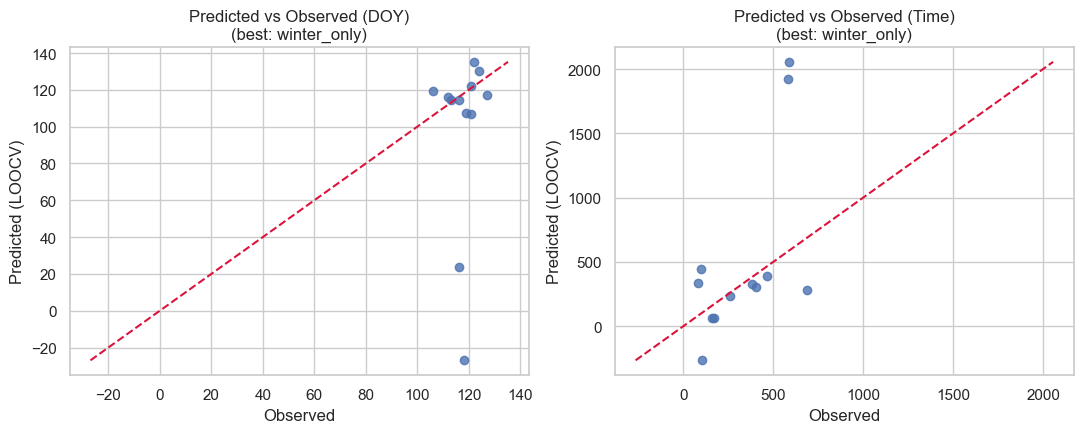

In [16]:
def best_feature_set(predictive_df, target):
    sub = predictive_df.query("target == @target and status == 'ok'").copy()
    if sub.empty:
        return None
    return sub.sort_values("rmse", ascending=True).iloc[0]["feature_set"]

best_doy = best_feature_set(predictive_compare, "doy")
best_time = best_feature_set(predictive_compare, "minutes_since_midnight")

print("Best feature set for DOY:", best_doy)
print("Best feature set for time-of-day:", best_time)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, target, title, details in [
    (axes[0], "doy", "Predicted vs Observed (DOY)", pred_doy_details),
    (axes[1], "minutes_since_midnight", "Predicted vs Observed (Time)", pred_time_details),
]:
    best = best_feature_set(predictive_compare, target)
    if best is None:
        ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center")
        ax.set_axis_off()
        continue

    y_true = details[(target, best)]["y_true"]
    y_pred = details[(target, best)]["y_pred"]

    ax.scatter(y_true, y_pred, alpha=0.8)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], color="crimson", linestyle="--")
    ax.set_title(f"{title}\n(best: {best})")
    ax.set_xlabel("Observed")
    ax.set_ylabel("Predicted (LOOCV)")

plt.tight_layout()
plt.show()


## 14) Quick visuals for climate relationships


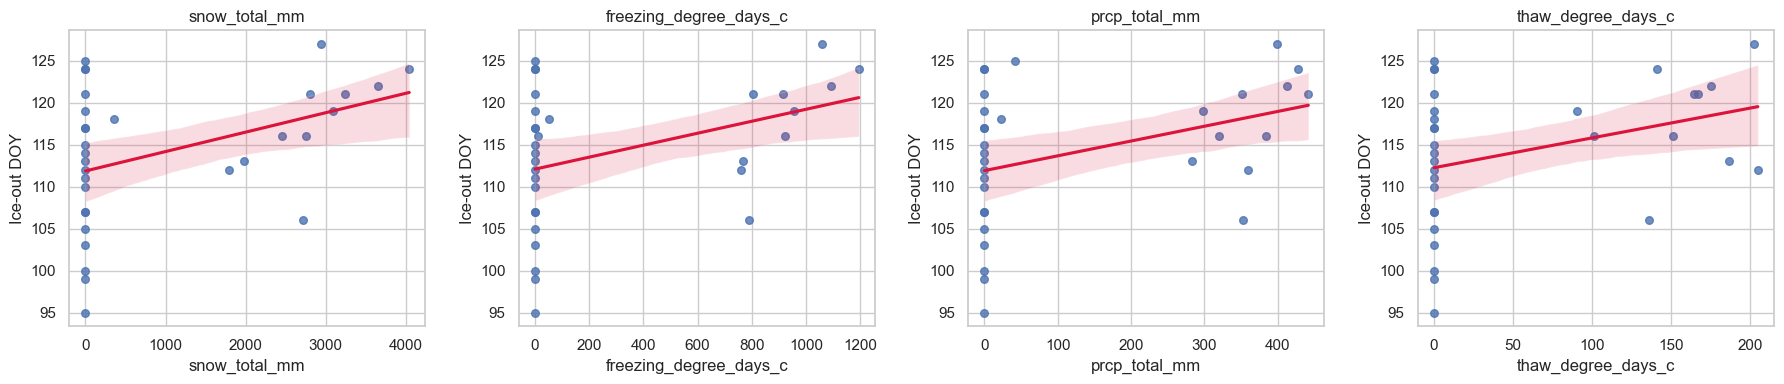

In [17]:
if not corr_df.empty:
    top_metrics = corr_df["metric"].head(4).tolist()
    n = len(top_metrics)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4), squeeze=False)
    for i, m in enumerate(top_metrics):
        ax = axes[0, i]
        sns.regplot(data=analysis_df, x=m, y="doy", ax=ax, scatter_kws={"s": 30, "alpha": 0.8}, line_kws={"color": "crimson"})
        ax.set_title(m)
        ax.set_ylabel("Ice-out DOY")
    plt.tight_layout()
    plt.show()
else:
    print("No correlation table yet; check data availability and rerun above cells.")

## 15) Notes and next steps

- If `SNOW`/`SNWD` coverage is weak, select another station from `station_rank` and rerun from section 8.
- Fixed-window prediction now uses a multi-station daily composite (nearest non-null per variable/day), with no statistical infilling.
- Compact models in section 17 avoid temporal predictors and favor small feature sets with enough complete rows.
- If compact models remain insufficient, the next fallback is PRISM, then Daymet, for Jan 1-Mar 1 metrics.


## 16) Fixed pre-season window metrics (Jan 1 -> Mar 1) using multi-station composites

This is a non-circular prediction window because it does not depend on the unknown ice-out date.
To improve coverage without infilling, daily values are composed from multiple nearby stations:
- For each day/variable, take the nearest station with a non-missing value.
- No statistical backfilling of missing observations is performed.


In [ ]:
FIXED_WINDOW_START = (1, 1)
FIXED_WINDOW_END = (3, 13)
PREDICTION_YEAR = 2026
MULTI_STATION_COUNT = 8


def compute_fixed_window(year, start_md=FIXED_WINDOW_START, end_md=FIXED_WINDOW_END):
    start = pd.Timestamp(year=year, month=start_md[0], day=start_md[1])
    end = pd.Timestamp(year=year, month=end_md[0], day=end_md[1])
    return start, end


# Use top nearby stations by prior coverage ranking (distance + data completeness).
composite_station_rank = station_rank.copy().sort_values(
    ["coverage_mean", "temp_est_coverage", "SNOW_coverage", "SNWD_coverage", "distance_km"],
    ascending=[False, False, False, False, True],
).reset_index(drop=True)
COMPOSITE_STATIONS = composite_station_rank.head(MULTI_STATION_COUNT)["station"].tolist()

print("Composite station pool:")
display(composite_station_rank.head(MULTI_STATION_COUNT)[["station", "name", "distance_km", "coverage_mean", "temp_est_coverage", "SNOW_coverage", "SNWD_coverage"]])


def fetch_station_window(station, start, end):
    ds = fetch_ncei_daily(
        station,
        start.strftime("%Y-%m-%d"),
        end.strftime("%Y-%m-%d"),
        force=REFRESH_NCEI_CACHE,
    )
    ds = normalize_numeric(ds, NCEI_DTYPES)
    if ds.empty or "DATE" not in ds.columns:
        return pd.DataFrame(columns=["DATE", "station", "station_order", "TEMP_EST", "PRCP", "SNOW", "SNWD"])

    ds = ds.sort_values("DATE").copy()
    temp_est, _, _, _, _ = temp_estimate_series(ds)

    out = pd.DataFrame({
        "DATE": pd.to_datetime(ds["DATE"], errors="coerce"),
        "station": station,
        "TEMP_EST": temp_est,
        "PRCP": ds["PRCP"] if "PRCP" in ds else np.nan,
        "SNOW": ds["SNOW"] if "SNOW" in ds else np.nan,
        "SNWD": ds["SNWD"] if "SNWD" in ds else np.nan,
    })
    return out.dropna(subset=["DATE"])


def first_non_null_by_date(long_df, value_col):
    x = long_df[["DATE", "station", "station_order", value_col]].dropna(subset=[value_col]).copy()
    if x.empty:
        return pd.DataFrame(columns=["DATE", value_col, f"{value_col}_station"])

    x = x.sort_values(["DATE", "station_order"])
    first = x.groupby("DATE", as_index=False).first()
    first = first.rename(columns={"station": f"{value_col}_station"})
    return first[["DATE", value_col, f"{value_col}_station"]]


def build_composite_daily(stations, start, end):
    date_frame = pd.DataFrame({"DATE": pd.date_range(start, end, freq="D")})

    parts = []
    station_order = {s: i for i, s in enumerate(stations)}
    for st in stations:
        d = fetch_station_window(st, start, end)
        if d.empty:
            continue
        d["station_order"] = station_order[st]
        parts.append(d)

    if not parts:
        return date_frame.assign(TEMP_EST=np.nan, PRCP=np.nan, SNOW=np.nan, SNWD=np.nan)

    long_df = pd.concat(parts, ignore_index=True)

    temp = first_non_null_by_date(long_df, "TEMP_EST")
    prcp = first_non_null_by_date(long_df, "PRCP")
    snow = first_non_null_by_date(long_df, "SNOW")
    snwd = first_non_null_by_date(long_df, "SNWD")

    comp = date_frame.merge(temp, on="DATE", how="left")
    comp = comp.merge(prcp, on="DATE", how="left")
    comp = comp.merge(snow, on="DATE", how="left")
    comp = comp.merge(snwd, on="DATE", how="left")
    return comp.sort_values("DATE").reset_index(drop=True)


def summarize_fixed_window_from_composite(year, stations):
    start, end = compute_fixed_window(int(year))
    comp = build_composite_daily(stations, start, end)

    t = pd.to_numeric(comp["TEMP_EST"], errors="coerce")
    prcp = pd.to_numeric(comp["PRCP"], errors="coerce")
    snow = pd.to_numeric(comp["SNOW"], errors="coerce")
    snwd = pd.to_numeric(comp["SNWD"], errors="coerce")

    return {
        "year": int(year),
        "fw_start": start,
        "fw_end": end,
        "fw_days": (end - start).days + 1,
        "fw_n_daily_rows": len(comp),
        "fw_temp_mean_c": t.mean(skipna=True),
        "fw_temp_std_c": t.std(skipna=True),
        "fw_freezing_degree_days_c": np.maximum(0, 0 - t).sum(skipna=True),
        "fw_thaw_degree_days_c": np.maximum(0, t - 0).sum(skipna=True),
        "fw_prcp_total_mm": prcp.sum(skipna=True),
        "fw_snow_total_mm": snow.sum(skipna=True),
        "fw_snwd_max_mm": snwd.max(skipna=True),
        "fw_temp_est_cov": t.notna().mean(),
        "fw_prcp_cov": prcp.notna().mean(),
        "fw_snow_cov": snow.notna().mean(),
        "fw_snwd_cov": snwd.notna().mean(),
    }


fixed_rows = [summarize_fixed_window_from_composite(y, COMPOSITE_STATIONS) for y in sorted(ice["year"].unique())]
fixed_df = pd.DataFrame(fixed_rows).sort_values("year").reset_index(drop=True)
fixed_analysis_df = ice.merge(fixed_df, on="year", how="left")

fixed_analysis_df.head()


## 17) Fixed-window correlations and compact-model readiness

Correlations are shown for both targets:
- Ice-out date (`doy`)
- Ice-out time-of-day (`minutes_since_midnight`)

Then a compact feature set is selected (without temporal predictors and without backfilling)
for date and time models separately.


In [19]:
from itertools import combinations

fixed_features = [
    "fw_temp_mean_c",
    "fw_temp_std_c",
    "fw_freezing_degree_days_c",
    "fw_thaw_degree_days_c",
    "fw_prcp_total_mm",
    "fw_snow_total_mm",
    "fw_snwd_max_mm",
]


def corr_table_vs_target(df, target_col, features):
    rows = []
    for f in features:
        sub = df[[target_col, f]].dropna()
        if len(sub) < 5:
            continue
        pear = stats.pearsonr(sub[f], sub[target_col])
        spear = stats.spearmanr(sub[f], sub[target_col], nan_policy="omit")
        rows.append({
            "target": target_col,
            "metric": f,
            "n": len(sub),
            "pearson_r": pear.statistic,
            "pearson_p": pear.pvalue,
            "spearman_rho": spear.statistic,
            "spearman_p": spear.pvalue,
            "abs_pearson_r": abs(pear.statistic),
        })
    return pd.DataFrame(rows).sort_values("abs_pearson_r", ascending=False) if rows else pd.DataFrame()


def select_compact_feature_set(df, target_col, candidate_features, min_rows=9, max_features=3):
    best = None
    for k in range(max_features, 1, -1):
        for combo in combinations(candidate_features, k):
            combo = list(combo)
            d = df[combo + [target_col]].dropna()
            n = len(d)
            if n < min_rows:
                continue

            cv = loocv_linear_regression(df, combo, target_col, min_samples=min_rows)
            if cv["status"] != "ok":
                continue

            score = (cv["rmse"], -n)
            if (best is None) or (score < best["score"]):
                best = {
                    "features": combo,
                    "rmse": cv["rmse"],
                    "mae": cv["mae"],
                    "cv_r2": cv["cv_r2"],
                    "pred_obs_spearman": cv["pred_obs_spearman"],
                    "n": n,
                    "score": score,
                }

    return best


fixed_corr_doy = corr_table_vs_target(fixed_analysis_df, "doy", fixed_features)
fixed_corr_time = corr_table_vs_target(fixed_analysis_df, "minutes_since_midnight", fixed_features)

print("Top fixed-window correlations vs DOY")
display(fixed_corr_doy)
print("Top fixed-window correlations vs time-of-day")
display(fixed_corr_time)

fixed_model_df = fixed_analysis_df[["year", "doy", "minutes_since_midnight", *fixed_features]].copy()

feature_coverage = pd.DataFrame({
    "feature": fixed_features,
    "non_null_rows": [fixed_model_df[f].notna().sum() for f in fixed_features],
    "coverage": [fixed_model_df[f].notna().mean() for f in fixed_features],
}).sort_values(["non_null_rows", "coverage"], ascending=False)

print("Fixed-window feature coverage across historical years")
display(feature_coverage)

compact_doy = select_compact_feature_set(fixed_model_df, "doy", fixed_features, min_rows=9, max_features=3)
compact_time = select_compact_feature_set(fixed_model_df, "minutes_since_midnight", fixed_features, min_rows=9, max_features=3)

compact_summary = pd.DataFrame([
    {
        "target": "doy",
        "selected_features": None if compact_doy is None else ", ".join(compact_doy["features"]),
        "n": None if compact_doy is None else compact_doy["n"],
        "loocv_rmse": None if compact_doy is None else compact_doy["rmse"],
        "loocv_mae": None if compact_doy is None else compact_doy["mae"],
        "loocv_r2": None if compact_doy is None else compact_doy["cv_r2"],
        "loocv_spearman": None if compact_doy is None else compact_doy["pred_obs_spearman"],
    },
    {
        "target": "minutes_since_midnight",
        "selected_features": None if compact_time is None else ", ".join(compact_time["features"]),
        "n": None if compact_time is None else compact_time["n"],
        "loocv_rmse": None if compact_time is None else compact_time["rmse"],
        "loocv_mae": None if compact_time is None else compact_time["mae"],
        "loocv_r2": None if compact_time is None else compact_time["cv_r2"],
        "loocv_spearman": None if compact_time is None else compact_time["pred_obs_spearman"],
    },
])

display(compact_summary)


Top fixed-window correlations vs DOY


,target,metric,n,pearson_r,pearson_p,spearman_rho,spearman_p,abs_pearson_r
0,doy,fw_temp_mean_c,10,-0.756008,0.011411,-0.601826,0.065646,0.756008
2,doy,fw_freezing_degree_days_c,32,0.373575,0.035195,0.383418,0.030296,0.373575
6,doy,fw_snwd_max_mm,23,0.223557,0.305173,0.248576,0.252742,0.223557
3,doy,fw_thaw_degree_days_c,32,0.168605,0.356292,0.287173,0.111018,0.168605
4,doy,fw_prcp_total_mm,32,-0.154718,0.397831,-0.099050,0.589648,0.154718
1,doy,fw_temp_std_c,10,-0.129271,0.721899,0.085107,0.815172,0.129271
5,doy,fw_snow_total_mm,32,-0.100597,0.583819,-0.009711,0.957933,0.100597


Top fixed-window correlations vs time-of-day


,target,metric,n,pearson_r,pearson_p,spearman_rho,spearman_p,abs_pearson_r
1,minutes_since_midnight,fw_temp_std_c,10,0.510747,0.131408,0.503030,0.138334,0.510747
2,minutes_since_midnight,fw_freezing_degree_days_c,32,-0.380303,0.031782,-0.365006,0.039965,0.380303
5,minutes_since_midnight,fw_snow_total_mm,32,-0.227566,0.210350,-0.221233,0.223665,0.227566
4,minutes_since_midnight,fw_prcp_total_mm,32,-0.173344,0.342733,-0.048126,0.793658,0.173344
3,minutes_since_midnight,fw_thaw_degree_days_c,32,-0.169814,0.352803,-0.293633,0.102861,0.169814
0,minutes_since_midnight,fw_temp_mean_c,10,0.149369,0.680448,0.345455,0.328227,0.149369
6,minutes_since_midnight,fw_snwd_max_mm,23,-0.077538,0.725098,-0.018789,0.932190,0.077538


Fixed-window feature coverage across historical years


,feature,non_null_rows,coverage
2,fw_freezing_degree_days_c,32,1.00000
3,fw_thaw_degree_days_c,32,1.00000
4,fw_prcp_total_mm,32,1.00000
5,fw_snow_total_mm,32,1.00000
6,fw_snwd_max_mm,23,0.71875
0,fw_temp_mean_c,10,0.31250
1,fw_temp_std_c,10,0.31250


,target,selected_features,n,loocv_rmse,loocv_mae,loocv_r2,loocv_spearman
0,doy,"fw_temp_std_c, fw_snow_total_mm, fw_snwd_max_mm",9,3.921020,3.678293,0.597763,0.711303
1,minutes_since_midnight,"fw_temp_std_c, fw_snow_total_mm, fw_snwd_max_mm",9,126.566756,104.756031,0.158289,0.483333


## 18) Predict 2026 ice-out from fixed-window multi-station compact models

This step uses Jan 1 -> Mar 1 composite metrics for 2026, then applies simple OLS models
with compact feature sets selected in section 17.
If training rows are still insufficient, use PRISM/Daymet as the next data source.


In [20]:
def fit_ols_predict(train_df, feature_cols, target_col, pred_row):
    d = train_df[feature_cols + [target_col]].dropna().copy()
    n = len(d)
    p = len(feature_cols)
    if n < p + 3:
        return {"status": "insufficient_rows", "n": n, "p": p, "prediction": np.nan, "resid_std": np.nan}

    x = d[feature_cols].to_numpy(dtype=float)
    y = d[target_col].to_numpy(dtype=float)

    mu = x.mean(axis=0)
    sd = x.std(axis=0, ddof=0)
    sd[sd == 0] = 1.0

    xz = (x - mu) / sd
    X = np.column_stack([np.ones(n), xz])
    beta = np.linalg.pinv(X) @ y

    yhat = X @ beta
    dof = max(1, n - (p + 1))
    resid_std = float(np.sqrt(np.sum((y - yhat) ** 2) / dof))

    xr = pred_row[feature_cols].to_numpy(dtype=float).ravel()
    if np.isnan(xr).any():
        missing = [f for f, v in zip(feature_cols, xr) if pd.isna(v)]
        return {
            "status": "missing_prediction_features",
            "n": n,
            "p": p,
            "prediction": np.nan,
            "resid_std": resid_std,
            "missing_features": missing,
        }

    xrz = (xr - mu) / sd
    pred = float(np.r_[1.0, xrz] @ beta)

    return {
        "status": "ok",
        "n": n,
        "p": p,
        "prediction": pred,
        "resid_std": resid_std,
    }


pred_metrics = summarize_fixed_window_from_composite(PREDICTION_YEAR, COMPOSITE_STATIONS)
pred_feature_row = pd.DataFrame([pred_metrics])

# Historical-only training rows.
train_fixed = fixed_model_df.query("year != @PREDICTION_YEAR").copy()

selected_doy_features = [] if compact_doy is None else compact_doy["features"]
selected_time_features = [] if compact_time is None else compact_time["features"]

if not selected_doy_features:
    res_doy = {"status": "insufficient_rows", "n": 0, "p": 0, "prediction": np.nan, "resid_std": np.nan}
else:
    res_doy = fit_ols_predict(train_fixed, selected_doy_features, "doy", pred_feature_row)

if not selected_time_features:
    res_time = {"status": "insufficient_rows", "n": 0, "p": 0, "prediction": np.nan, "resid_std": np.nan}
else:
    res_time = fit_ols_predict(train_fixed, selected_time_features, "minutes_since_midnight", pred_feature_row)

prediction_summary = pd.DataFrame([
    {
        "target": "doy",
        "selected_features": ", ".join(selected_doy_features) if selected_doy_features else None,
        "status": res_doy["status"],
        "n_train": res_doy.get("n"),
        "p_features": res_doy.get("p"),
        "prediction": res_doy.get("prediction"),
        "approx_95pct_low": None if pd.isna(res_doy.get("prediction", np.nan)) else res_doy["prediction"] - 1.96 * res_doy["resid_std"],
        "approx_95pct_high": None if pd.isna(res_doy.get("prediction", np.nan)) else res_doy["prediction"] + 1.96 * res_doy["resid_std"],
    },
    {
        "target": "minutes_since_midnight",
        "selected_features": ", ".join(selected_time_features) if selected_time_features else None,
        "status": res_time["status"],
        "n_train": res_time.get("n"),
        "p_features": res_time.get("p"),
        "prediction": res_time.get("prediction"),
        "approx_95pct_low": None if pd.isna(res_time.get("prediction", np.nan)) else res_time["prediction"] - 1.96 * res_time["resid_std"],
        "approx_95pct_high": None if pd.isna(res_time.get("prediction", np.nan)) else res_time["prediction"] + 1.96 * res_time["resid_std"],
    },
])

display(prediction_summary)

if res_doy["status"] == "ok" and res_time["status"] == "ok":
    pred_doy = int(np.clip(np.round(res_doy["prediction"]), 1, 366))
    pred_date = pd.Timestamp(year=PREDICTION_YEAR, month=1, day=1) + pd.Timedelta(days=pred_doy - 1)

    pred_minutes = int(np.clip(np.round(res_time["prediction"]), 0, 1439))
    pred_h = pred_minutes // 60
    pred_m = pred_minutes % 60

    print(f"Predicted {PREDICTION_YEAR} ice-out date: {pred_date.date()} (DOY={pred_doy})")
    print(f"Predicted {PREDICTION_YEAR} ice-out time: {pred_h:02d}:{pred_m:02d} local clock time")
else:
    print("Prediction not available with current station-only composite coverage.")
    print("Next step: add gridded climate fallback (PRISM first, then Daymet) for Jan 1-Mar 1 metrics.")

print("2026 composite-window coverage diagnostics:")
display(pred_feature_row[["fw_temp_est_cov", "fw_prcp_cov", "fw_snow_cov", "fw_snwd_cov"]])


,target,selected_features,status,n_train,p_features,prediction,approx_95pct_low,approx_95pct_high
0,doy,"fw_temp_std_c, fw_snow_total_mm, fw_snwd_max_mm",missing_prediction_features,9,3,NaN,None,None
1,minutes_since_midnight,"fw_temp_std_c, fw_snow_total_mm, fw_snwd_max_mm",missing_prediction_features,9,3,NaN,None,None


Prediction not available with current station-only composite coverage.
Next step: add gridded climate fallback (PRISM first, then Daymet) for Jan 1-Mar 1 metrics.
2026 composite-window coverage diagnostics:


,fw_temp_est_cov,fw_prcp_cov,fw_snow_cov,fw_snwd_cov
0,0.0,0.866667,0.816667,0.283333
